In [1]:
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
%matplotlib inline
import numpy as np
from numpy import linalg as LA
from scipy import linalg
from scipy import stats
from pylab import * 
#from tempfile import TemporaryFile
P = open("/home/jose/SusanaUno/Prices.txt","rb")
S = open("/home/jose/SusanaUno/Symbols.txt","r")
D = open("/home/jose/SusanaUno/Dates.txt","r")
G = open("/home/jose/SusanaUno/Gics.txt","r")


In [2]:
s=[]
lines=S.readlines()
S.close()
for line in lines:
	values = line.split()
	s.append(values[0])
lensymbols=len(s)

d=[]
lines=D.readlines()
D.close() 
for line in lines:
	values = line.split()
	d.append(values[0])
#print type(values)	
lendates=len(d)

g=[]
lines=G.readlines()
G.close()
for line in lines:
	values = line.split()
	g.append(values[0])
    
Prices=np.loadtxt("Prices.txt")      
lenPrices=len(Prices)



In [5]:
#----- Rendimientos---

Returns=[]

for i in range(lensymbols):
	Returns.append([])
	for j in range(1,lendates):
		r=(Prices[i][j]/Prices[i][j-1])-1
                Returns[-1].append(r)
Returns=np.asarray(Returns)
#print len(Returns)

In [5]:
#
#total=[]
e=.01
q=1+e
q1=q+1
k=0
mat=[]
dias=44
shift=22
lenret=len(Returns)
nummat=(len(Returns[0])-dias)/shift
Corr=np.zeros((lenret,lenret))
Cq=np.zeros((lenret,lenret))
for z in xrange(nummat):
    #total.append([])
    for i in xrange(lenret):
        mat.append([])
        for j in xrange(dias):
            mat[i].append(Returns[i][j+k])
    k+=shift
    mat=np.asarray(mat)

#---normalizando--
    for i in xrange(lenret):
        mean=np.mean(mat[i])
        var=np.std(mat[i])
        mat[i]=(mat[i]-mean)/var
#--- checa si esta normalizado
   # for i in xrange(lenret):
    #    mean=np.mean(mat[i])
     #   var=np.std(mat[i])
    #print mean,var

#--- matriz de correlacion--
    Corr=np.corrcoef(mat)
    #print Corr
    #mat=[]
    f= open("MatrizCorr%d.dat"%z,"w")
    for renglon in xrange(lenret):
        #recorte=str(Corr[renglon])
        #recorte=recorte[1:-1]
        for item in Corr[renglon]:
            f.write(str(item)+" ")
        f.write("\n")
    #print len(Corr[73])
    f.close()
    
#---powermap---
    for i in xrange(lenret):
        for j in xrange(i,lenret):
            XX=Corr[i][j]
            Cq[i][j]= (abs(XX)**q1)/XX
            Cq[j][i]=Cq[i][j]
    f= open("MatrizCorrPM%dq%.2f.dat"%(z,q),"w")
    for renglon in xrange(lenret):
        for item in Cq[renglon]:
            f.write(str(item)+" ")
        f.write("\n")
    #print len(Corr[73])
    f.close()
## diagonaliza Cq  
    w1, v1 = LA.eigh(Cq)
    
    f= open("evalorPM%dq%.2f.dat"%(z,q),"w")
    for line in xrange(lenret):
        f.write(str(w1[line])+"\n")
    f.close
    f= open("evectorPM%dq%.2f.dat"%(z,q),"w")
    
    for renglon in xrange(lenret):
        for item in v1[renglon]:
            f.write(str(item)+" ")
            
            #print item
        f.write("\n")
    
    f.close
    
#---diagonaliza Corr   
    w, v = LA.eigh(Corr)
    
    f= open("evalor%d.dat"%z,"w")
    for line in xrange(lenret):
        f.write(str(w[line])+"\n")
    f.close
    fil= open("evector%d.dat"%z,"w")
    
    for renglon in xrange(lenret):
        for item in v[renglon]:
            fil.write(str(item)+" ")
            
            #print item
        fil.write("\n")
    
    fil.close

    mat=[]

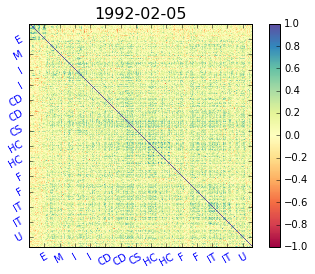

In [5]:
#visualización de matriz de corr
i=2
num=20
sector=g[:293:num]
sector2=["E","M","I","I","CD","CD","CS","HC","HC","F","F","IT","IT","U"]

fecha=d[i]
indice = np.arange(num,293,num)
c=np.loadtxt("MatrizCorr%d.dat"%i)
im=plt.imshow(c,interpolation='nearest',cmap=plt.get_cmap("Spectral"))
plt.colorbar()
im.set_clim(-1.0, 1.0)    
plt.xticks(indice,sector2, color = 'b', rotation = 30) 
plt.yticks(indice,sector2, color = 'b', rotation = 30) 
plt.title("%s" %fecha,fontsize=16)

In [3]:
##haciendo todas las figuras de las matrices de CORR

#fecha=d[0]
num=20
indice = np.arange(num,293,num)
sector=g[:293:num]
sector2=["E","M","I","I","CD","CD","CS","HC","HC","F","F","IT","IT","U"]
for i in xrange(262):
    fecha=d[i*22]
    

    #print i , fecha
    c=np.loadtxt("MatrizCorr%d.dat"%i)
    im=plt.imshow(c,interpolation='nearest',cmap=plt.get_cmap('rainbow'))
    plt.colorbar()
    im.set_clim(-1.0, 1.0) 
    plt.xticks(indice,sector2, color = 'b', rotation = 30) 
    plt.yticks(indice,sector2, color = 'b', rotation = 30)
    plt.title("%s" %fecha,fontsize=16)
    titulo="/cueva/Susana/SusanaDos/figMatCorr2/FigMat%d.png"%i
    savefig(titulo, bbox_inches='tight')
    plt.clf()
    plt.close()
    